<div style="
    border: 2px solid #333;
    padding: 14px 20px;
    margin: 15px auto 25px auto;
    width: 85%;
    max-width: 900px;
    box-sizing: border-box;
    text-align: center;
">
    <h1 style="margin: 0;"><b>Feature Detection and Object Tracking</b></h1>
</div>

This notebook implements feature-based object tracking in video using ORB keypoints, brute-force descriptor matching, homography estimation with RANSAC, and perspective transformation of an initial bounding box.

## Problem Statement

Given a video sequence and an initial bounding box around an object in the first frame, the objective is to locate the same object in subsequent frames.

ORB keypoints and binary descriptors are extracted from the object region in the first frame and matched against features detected in each new frame. A homography is estimated from the matched correspondences to map the original bounding box into the current frame.

## Objectives

- Define the object using an initial bounding box.
- Detect ORB keypoints and descriptors inside the object region.
- Detect ORB features in subsequent frames.
- Match binary descriptors using Hamming distance.
- Estimate a robust homography using RANSAC.
- Transform the initial bounding box to track the object.
- Visualize representative tracking results and inlier matches.
- Measure descriptor matches and RANSAC inliers across the sequence.

## Approach

```text
First frame + initial bounding box
        ↓
ORB features inside the object region
        ↓
ORB features in the current frame
        ↓
Brute-force descriptor matching
        ↓
Matched point correspondences
        ↓
RANSAC homography estimation
        ↓
Perspective transformation
        ↓
Tracked bounding box
```

## Assumptions

- The object contains enough distinctive local texture for ORB.
- The object can be approximated by a planar projective transformation.
- At least four valid point correspondences are required for homography estimation.
- The initial bounding box is known in the first frame.
- Invalid frames are rejected instead of forcing an unreliable transformation.

## 0. Setup

In [18]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=4, suppress=True)

## 1. Data Path

In [19]:
VIDEO_PATH = Path("../data/video1.mp4")

if not VIDEO_PATH.exists():
    raise FileNotFoundError(f"Video not found: {VIDEO_PATH}")

print(f"Input video: {VIDEO_PATH}")

Input video: ../data/video1.mp4


## 2. Output Directory

In [20]:
OUTPUT_DIR = Path("../outputs/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Tracking Parameters

In [21]:
row, col = 24, 46
height, width = 170, 160

MAX_FEATURES = 1000
RANSAC_THRESHOLD = 5.0
MIN_MATCHES = 4

bbox = np.float32([
    [col,         row],
    [col + width, row],
    [col + width, row + height],
    [col,         row + height],
]).reshape(-1, 1, 2)

print("Initial bounding box corners:")
print(bbox.reshape(-1, 2))

Initial bounding box corners:
[[ 46.  24.]
 [206.  24.]
 [206. 194.]
 [ 46. 194.]]


## 4. Initialize ORB and Descriptor Matcher

In [22]:
orb = cv2.ORB_create(nfeatures=MAX_FEATURES)
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

## 5. Read the Reference Frame

In [23]:
cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

ret, reference_frame = cap.read()
cap.release()

if not ret or reference_frame is None:
    raise RuntimeError("Could not read the first video frame.")

reference_gray = cv2.cvtColor(reference_frame, cv2.COLOR_BGR2GRAY)

print(f"Reference frame shape: {reference_frame.shape}")

Reference frame shape: (240, 320, 3)


## 6. Detect Reference Features Inside the Object Region

In [24]:
reference_mask = np.zeros(reference_gray.shape, dtype=np.uint8)
reference_mask[row:row + height, col:col + width] = 255

reference_keypoints, reference_descriptors = orb.detectAndCompute(
    reference_gray,
    reference_mask,
)

if reference_descriptors is None or len(reference_keypoints) < MIN_MATCHES:
    raise RuntimeError(
        "Not enough ORB features were detected inside the initial bounding box."
    )

print(f"Reference keypoints detected: {len(reference_keypoints)}")
print(f"Descriptor shape: {reference_descriptors.shape}")

Reference keypoints detected: 868
Descriptor shape: (868, 32)


## 7. Visualize the Reference Object and ORB Keypoints

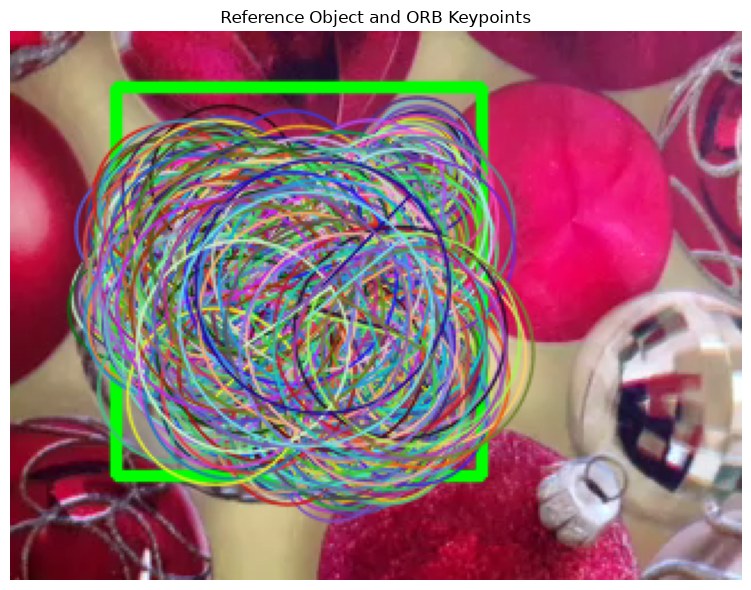

In [25]:
reference_with_bbox = reference_frame.copy()

cv2.polylines(
    reference_with_bbox,
    [np.int32(bbox)],
    True,
    (0, 255, 0),
    3,
    cv2.LINE_AA,
)

reference_features = cv2.drawKeypoints(
    reference_with_bbox,
    reference_keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)

reference_features_rgb = cv2.cvtColor(
    reference_features,
    cv2.COLOR_BGR2RGB,
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(reference_features_rgb)
ax.set_title("Reference Object and ORB Keypoints")
ax.axis("off")
plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "reference_orb_keypoints.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 8. Define Frame Matching and Homography Estimation

In [26]:
def match_and_estimate_homography(
    gray_frame,
    reference_keypoints,
    reference_descriptors,
    orb_detector,
    descriptor_matcher,
    min_matches=4,
    ransac_threshold=5.0,
):
    """Match ORB features and estimate the reference-to-current homography."""

    keypoints, descriptors = orb_detector.detectAndCompute(
        gray_frame,
        None,
    )

    if descriptors is None or len(keypoints) < min_matches:
        return None

    matches = descriptor_matcher.match(
        reference_descriptors,
        descriptors,
    )

    if len(matches) < min_matches:
        return None

    matches = sorted(matches, key=lambda match: match.distance)

    matched_reference_points = np.float32([
        reference_keypoints[match.queryIdx].pt
        for match in matches
    ]).reshape(-1, 2)

    matched_current_points = np.float32([
        keypoints[match.trainIdx].pt
        for match in matches
    ]).reshape(-1, 2)

    homography, inlier_mask = cv2.findHomography(
        matched_reference_points,
        matched_current_points,
        cv2.RANSAC,
        ransac_threshold,
    )

    if homography is None or inlier_mask is None:
        return None

    inlier_mask = inlier_mask.ravel().astype(bool)

    return {
        "keypoints": keypoints,
        "matches": matches,
        "homography": homography,
        "inlier_mask": inlier_mask,
        "num_matches": len(matches),
        "num_inliers": int(inlier_mask.sum()),
    }

## 9. Track the Object Through the Video

In [27]:
cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

tracking_results = []
frame_index = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    if frame_index == 0:
        frame_index += 1
        continue

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    result = match_and_estimate_homography(
        gray_frame=gray_frame,
        reference_keypoints=reference_keypoints,
        reference_descriptors=reference_descriptors,
        orb_detector=orb,
        descriptor_matcher=matcher,
        min_matches=MIN_MATCHES,
        ransac_threshold=RANSAC_THRESHOLD,
    )

    if result is None:
        tracking_results.append({
            "frame_index": frame_index,
            "success": False,
            "frame": frame.copy(),
            "num_matches": 0,
            "num_inliers": 0,
        })
        frame_index += 1
        continue

    current_bbox = cv2.perspectiveTransform(
        bbox,
        result["homography"],
    )

    annotated_frame = frame.copy()

    cv2.polylines(
        annotated_frame,
        [np.int32(current_bbox)],
        True,
        (0, 255, 0),
        3,
        cv2.LINE_AA,
    )

    tracking_results.append({
        "frame_index": frame_index,
        "success": True,
        "frame": annotated_frame,
        "raw_frame": frame.copy(),
        "current_bbox": current_bbox,
        "keypoints": result["keypoints"],
        "matches": result["matches"],
        "inlier_mask": result["inlier_mask"],
        "num_matches": result["num_matches"],
        "num_inliers": result["num_inliers"],
    })

    frame_index += 1

cap.release()

successful_results = [
    result for result in tracking_results
    if result["success"]
]

failed_results = [
    result for result in tracking_results
    if not result["success"]
]

print(f"Frames processed: {len(tracking_results)}")
print(f"Successful tracking frames: {len(successful_results)}")
print(f"Failed tracking frames: {len(failed_results)}")

Frames processed: 850
Successful tracking frames: 850
Failed tracking frames: 0


## 10. Tracking Summary

In [28]:
if not successful_results:
    raise RuntimeError(
        "No frame produced a valid homography. "
        "Check the video, ROI, or matching parameters."
    )

match_counts = np.array([
    result["num_matches"]
    for result in successful_results
])

inlier_counts = np.array([
    result["num_inliers"]
    for result in successful_results
])

inlier_ratios = inlier_counts / match_counts

print(f"Mean matches per successful frame: {match_counts.mean():.2f}")
print(f"Mean RANSAC inliers per successful frame: {inlier_counts.mean():.2f}")
print(f"Mean inlier ratio: {inlier_ratios.mean():.3f}")
print(f"Minimum inlier ratio: {inlier_ratios.min():.3f}")
print(f"Maximum inlier ratio: {inlier_ratios.max():.3f}")

Mean matches per successful frame: 381.80
Mean RANSAC inliers per successful frame: 290.49
Mean inlier ratio: 0.701
Minimum inlier ratio: 0.040
Maximum inlier ratio: 0.994


## 11. Visualize Representative Tracking Frames

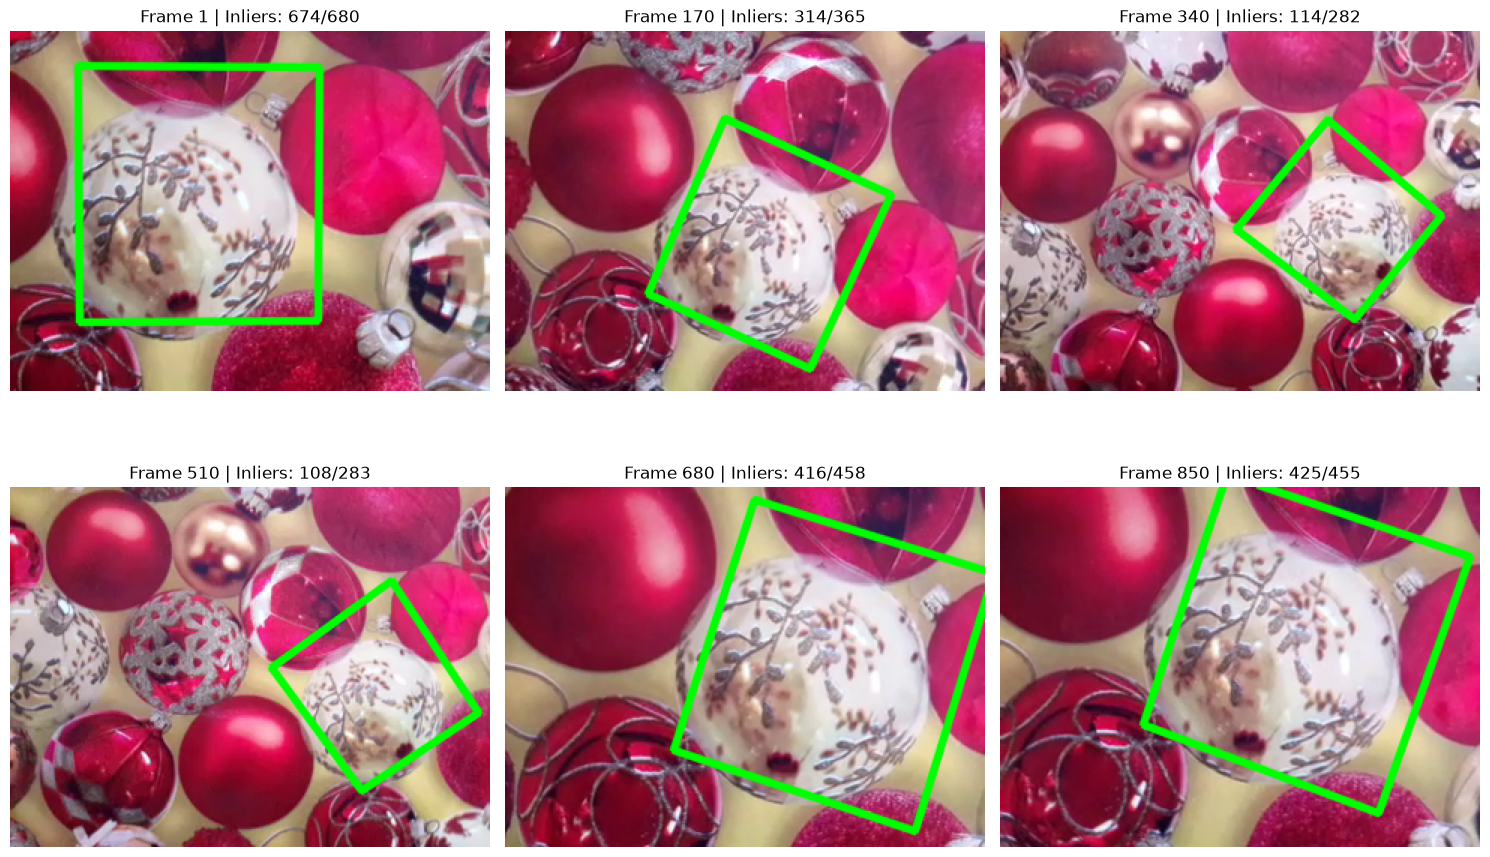

In [29]:
n_examples = min(6, len(successful_results))

sample_indices = np.linspace(
    0,
    len(successful_results) - 1,
    n_examples,
    dtype=int,
)

selected_results = [
    successful_results[index]
    for index in sample_indices
]

n_cols = 3
n_rows = int(np.ceil(n_examples / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 5 * n_rows),
)

axes = np.asarray(axes).reshape(-1)

for ax, result in zip(axes, selected_results):
    frame_rgb = cv2.cvtColor(
        result["frame"],
        cv2.COLOR_BGR2RGB,
    )

    ax.imshow(frame_rgb)
    ax.set_title(
        f"Frame {result['frame_index']} | "
        f"Inliers: {result['num_inliers']}/{result['num_matches']}"
    )
    ax.axis("off")

for ax in axes[n_examples:]:
    ax.axis("off")

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "representative_tracking_frames.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 12. Visualize Inlier Feature Matches

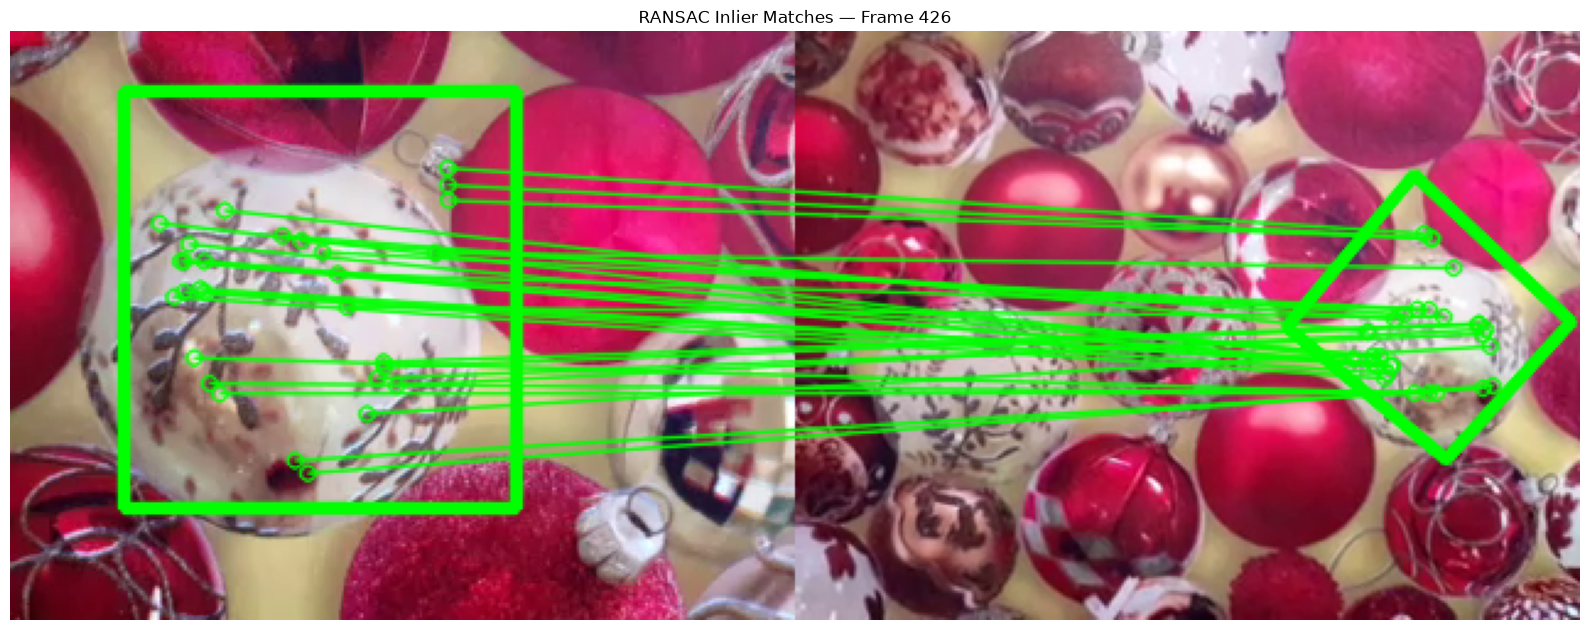

In [30]:
example_result = successful_results[len(successful_results) // 2]

matches_mask = example_result["inlier_mask"].astype(np.uint8).tolist()

reference_display = reference_frame.copy()

cv2.polylines(
    reference_display,
    [np.int32(bbox)],
    True,
    (0, 255, 0),
    3,
    cv2.LINE_AA,
)

current_display = example_result["raw_frame"].copy()

cv2.polylines(
    current_display,
    [np.int32(example_result["current_bbox"])],
    True,
    (0, 255, 0),
    3,
    cv2.LINE_AA,
)

match_visualization = cv2.drawMatches(
    reference_display,
    reference_keypoints,
    current_display,
    example_result["keypoints"],
    example_result["matches"],
    None,
    matchColor=(0, 255, 0),
    singlePointColor=None,
    matchesMask=matches_mask,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

match_visualization_rgb = cv2.cvtColor(
    match_visualization,
    cv2.COLOR_BGR2RGB,
)

fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(match_visualization_rgb)
ax.set_title(
    f"RANSAC Inlier Matches — Frame {example_result['frame_index']}"
)
ax.axis("off")
plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "ransac_inlier_matches.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 13. Matches and Inliers Across the Sequence

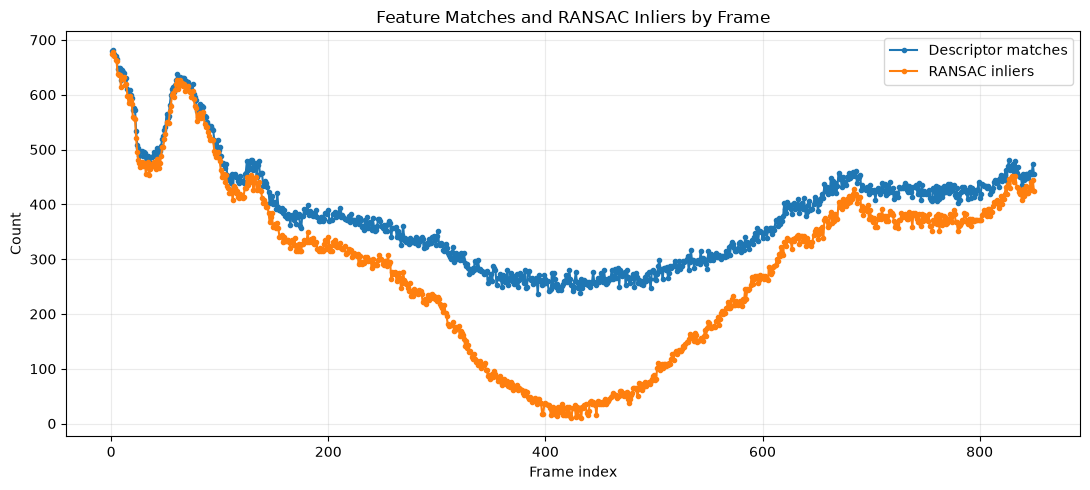

In [31]:
frame_indices = np.array([
    result["frame_index"]
    for result in successful_results
])

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    frame_indices,
    match_counts,
    marker=".",
    label="Descriptor matches",
)

ax.plot(
    frame_indices,
    inlier_counts,
    marker=".",
    label="RANSAC inliers",
)

ax.set_title("Feature Matches and RANSAC Inliers by Frame")
ax.set_xlabel("Frame index")
ax.set_ylabel("Count")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "matches_and_inliers_by_frame.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 14. Inlier Ratio Across the Sequence

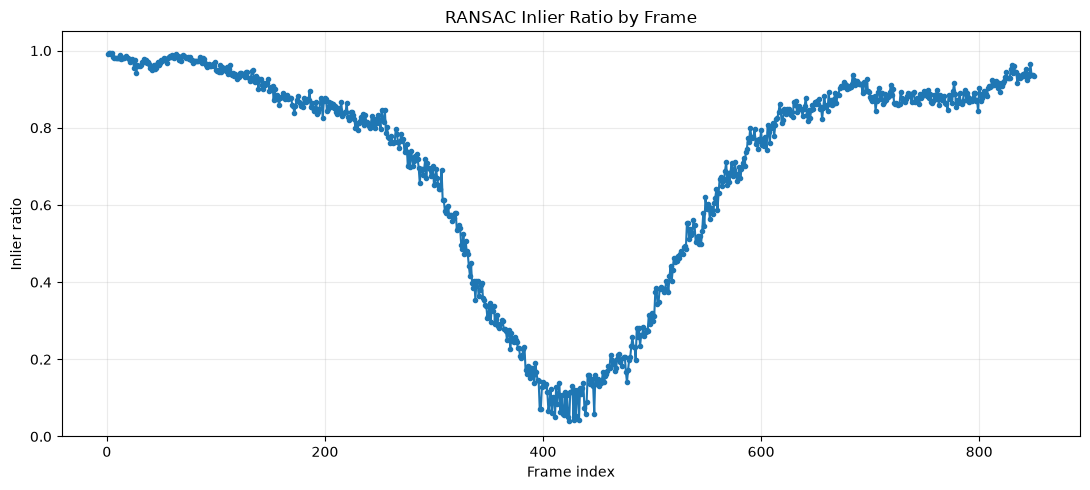

In [32]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    frame_indices,
    inlier_ratios,
    marker=".",
)

ax.set_title("RANSAC Inlier Ratio by Frame")
ax.set_xlabel("Frame index")
ax.set_ylabel("Inlier ratio")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "inlier_ratio_by_frame.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Discussion

The tracker uses the first frame as a fixed reference. ORB descriptors provide compact binary representations of local image regions, while the brute-force matcher compares these descriptors using Hamming distance.

The homography is estimated with RANSAC so that geometrically inconsistent matches can be rejected as outliers. The resulting transformation maps the four corners of the original bounding box into each successfully tracked frame.

Tracking quality depends on the stability of the detected features and the number of geometrically consistent correspondences. Frames with insufficient information are deliberately rejected instead of producing an unreliable bounding box.

The planar homography model is appropriate when the visible object surface behaves approximately as a plane or when perspective changes remain moderate. Strong non-rigid deformation, severe occlusion, motion blur, or large appearance changes can reduce tracking reliability.

## Conclusion

This laboratory demonstrates a feature-based object tracking pipeline using ORB feature detection and description, Hamming-distance descriptor matching, RANSAC homography estimation, and perspective transformation.

The method localizes the object in successive frames without requiring a dedicated tracking model. RANSAC inlier statistics provide an additional indication of the geometric consistency of the tracking result.